In [23]:
import numpy as np
import matplotlib.pyplot as plt

## What is Discrete-Time Fourier Series (DTFS)?

The Discrete-Time Fourier Series (DTFS) represents a periodic discrete-time signal as a sum of complex exponentials.

If a signal x[n] is periodic with period N, it can be expressed as:

$$
x[n] = \sum_{k=0}^{N-1} X[k] e^{j\frac{2\pi}{N}kn}
$$

The DTFS coefficients are given by:

$$
X[k] = \frac{1}{N} \sum_{n=0}^{N-1} x[n] e^{-j\frac{2\pi}{N}kn}
$$

Here:
- x[n] is a periodic discrete-time signal
- N is the period
- X[k] are the DTFS coefficients



## Important Properties of DTFS

- DTFS is defined only for periodic signals
- The number of frequency coefficients equals the signal period N
- The frequency representation is discrete and periodic
- DTFS describes the harmonic content of the signal


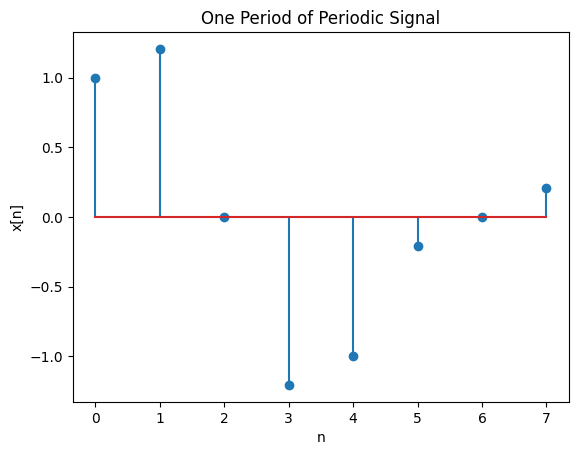

In [24]:
N = 8
n = np.arange(N)

# Periodic signal
x = np.cos(2*np.pi*n/N) + 0.5*np.sin(4*np.pi*n/N)


plt.stem(n, x)
plt.xlabel('n')
plt.ylabel('x[n]')
plt.title('One Period of Periodic Signal')
plt.show()

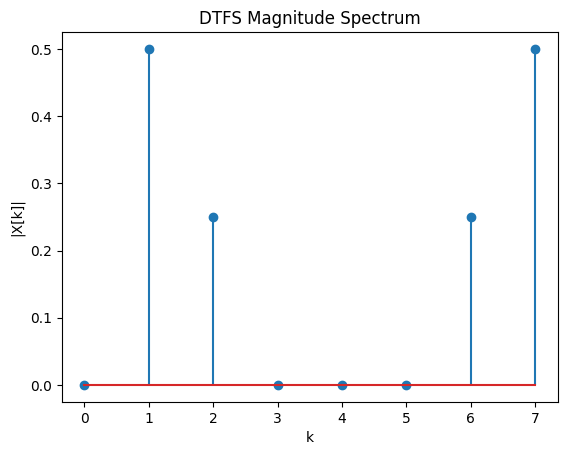

In [25]:
X_dtfs = np.zeros(N, dtype=complex)


for k in range(N):
    X_dtfs[k] = (1/N) * np.sum(x * np.exp(-1j*2*np.pi*k*n/N))


plt.stem(np.abs(X_dtfs))
plt.xlabel('k')
plt.ylabel('|X[k]|')
plt.title('DTFS Magnitude Spectrum')
plt.show()

Mathematically, negative frequencies are wrapped to the end of the spectrum because
the DTFS is periodic in frequency.

As a result, negative frequencies appear at high index values. To make the frequency content easier to interpret, we rearrange the DTFS coefficients
so that negative frequencies appear on the left.

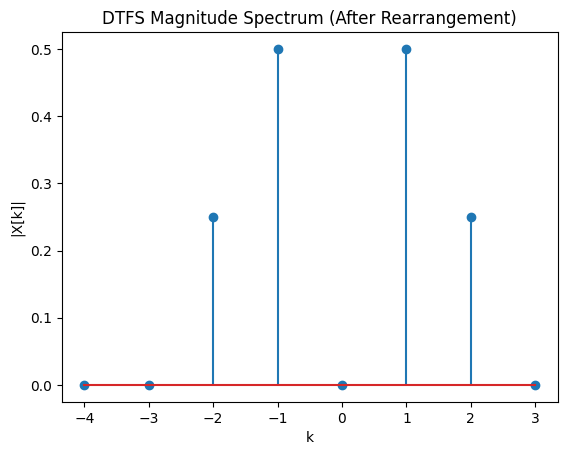

In [31]:
X_dtfs_reordered = np.concatenate((X_dtfs[N//2:], X_dtfs[:N//2]))
k_reordered = np.arange(-N//2, N//2)

plt.stem(k_reordered, np.abs(X_dtfs_reordered))
plt.xlabel('k')
plt.ylabel('|X[k]|')
plt.title('DTFS Magnitude Spectrum (After Rearrangement)')
plt.show()


## From DTFS to DFT

In practice, we often work with finite-length signals rather than explicitly periodic signals.

If we take one period of a periodic signal and compute its frequency representation, we obtain the Discrete Fourier Transform (DFT).

The relationship between DTFS and DFT is:

$$
X_{DTFS}[k] = \frac{1}{N} X_{DFT}[k]
$$

This shows that DTFS and DFT differ only by a scaling factor.


## What is the Discrete Fourier Transform (DFT)?

The Discrete Fourier Transform converts a finite-length discrete-time signal into its frequency-domain representation.

$$
X[k] = \sum_{n=0}^{N-1} x[n] e^{-j\frac{2\pi}{N}kn}
$$

Key points:
- DFT works for any finite-length signal
- DFT does not require periodicity
- Direct computation of DFT has complexity O(N^2)

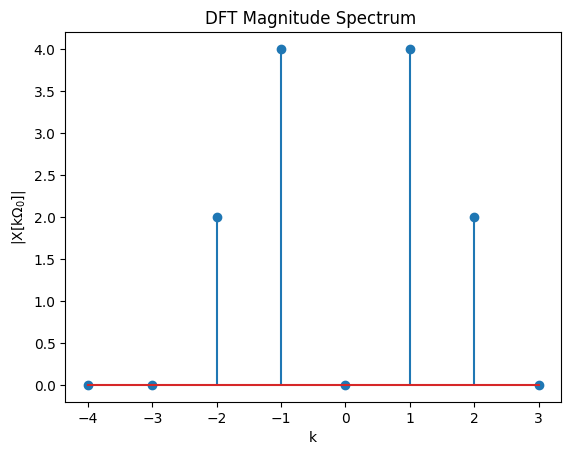

In [35]:

N = len(x)

# Fundamental frequency
Omega0 = 2 * np.pi / N

X_dft = np.zeros(N, dtype=complex)

for k in range(N):
    for n in range(N):
        X_dft[k] += x[n] * np.exp(-1j * k * Omega0 * n)

X_dft_shifted = np.concatenate((X_dft[N//2:], X_dft[:N//2]))
k_shifted = np.arange(-N//2, N//2)


plt.stem(k_shifted,np.abs(X_dft_shifted))
plt.xlabel('k')
plt.ylabel('|X[kΩ$_0$]|')
plt.title('DFT Magnitude Spectrum ')
plt.show()



## Why FFT is Needed

Computing the DFT directly requires N squared operations.

For large N, this becomes computationally expensive.

The Fast Fourier Transform (FFT) is an efficient algorithm that computes the DFT by:
- Splitting the signal into even and odd samples
- Exploiting symmetry and periodicity

The computational complexity of FFT is:

$$
O(N \log N)
$$


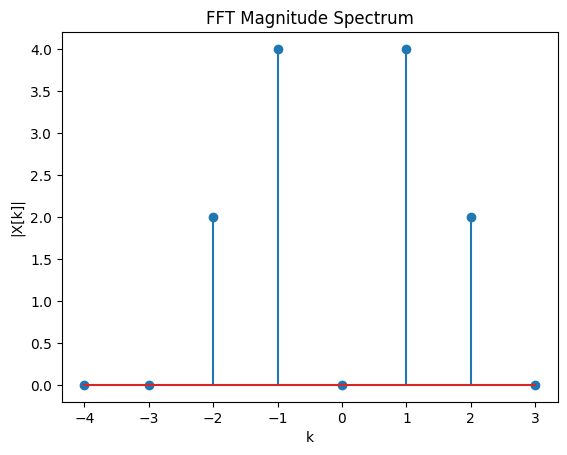

In [36]:
X_fft = np.fft.fft(x)
X_fft=np.fft.fftshift(X_fft)
k_fft = np.arange(-N//2, N//2)


plt.stem(k_fft,np.abs(X_fft))
plt.xlabel('k')
plt.ylabel('|X[k]|')
plt.title('FFT Magnitude Spectrum')
plt.show()

## Inverse FFT

The original time-domain signal can be recovered from its frequency-domain representation using the inverse FFT:

$$
x[n] = \text{IFFT}\{X[k]\}
$$

This confirms the duality between time and frequency domains.

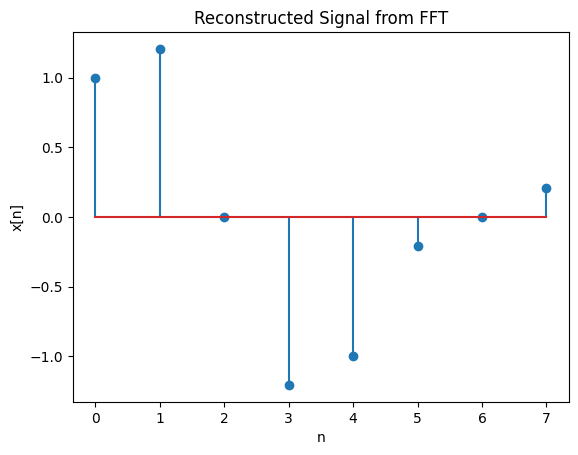

In [38]:
x_reconstructed = np.fft.ifft(np.fft.ifftshift(X_fft))


n = np.arange(N)

plt.stem(n, np.real(x_reconstructed))
plt.xlabel('n')
plt.ylabel('x[n]')
plt.title('Reconstructed Signal from FFT')
plt.show()

As mentioned earlier, we can also apply the **DFT/FFT** to aperiodic signals.


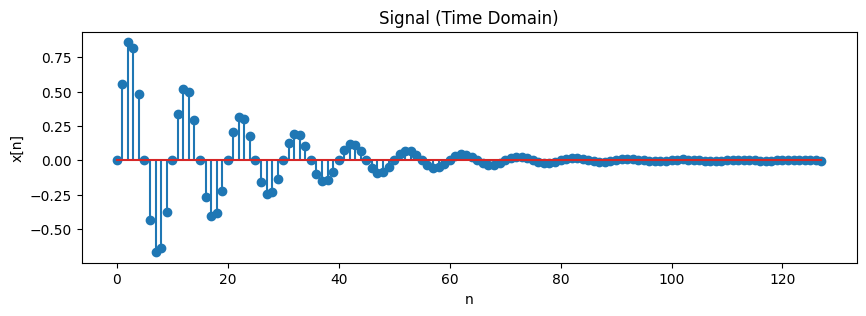

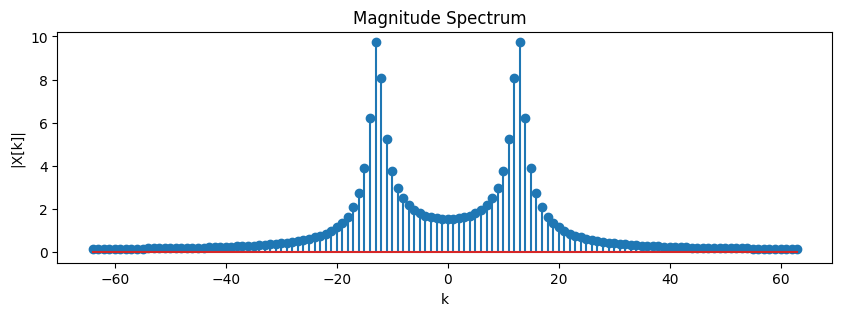

In [42]:
N = 128
n = np.arange(N)

x = np.exp(-0.05 * n) * np.sin(0.2 * np.pi * n)


X_fft = np.fft.fft(x)

X_fft_shifted = np.fft.fftshift(X_fft)

k = np.arange(-N//2, N//2)

plt.figure(figsize=(10, 3))
plt.stem(n, x)
plt.xlabel('n')
plt.ylabel('x[n]')
plt.title('Signal (Time Domain)')
plt.show()

plt.figure(figsize=(10, 3))
plt.stem(k, np.abs(X_fft_shifted))
plt.xlabel('k')
plt.ylabel('|X[k]|')
plt.title('Magnitude Spectrum  ')
plt.show()
